In [4]:
import numpy as np
import seaborn as sns
import pandas as pd

In [24]:
# KNN implementation for binary classification


class KNNClassifier:
    def __init__(self, k=3):
        self.k = k

    def _euclidean_dist(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def fit(self, X, y): #laazy learner
        self.X_train = X
        self.y_train = y

    def _predict_one(self, x):
        distance = [self._euclidean_dist(x, x_train) for x_train in self.X_train]
        knn_indices = np.argsort(distance)[:self.k]

        knn_classes = [self.y_train[i] for i in knn_indices]

        majority_class = np.argmax(np.bincount(knn_classes))
        return majority_class

    def predict(self, X):
        y_pred = [self._predict_one(x) for x in X]
        return np.array(y_pred)

In [ ]:
x1 = np.array([1, 2])
x2 = np.array([3, 4])

np.sqrt(np.sum((x1 - x2) ** 2))

np.float64(2.8284271247461903)

In [15]:
distance = [5.5, 2.5, 4.5, 1.5, 0.5]
np.argsort(distance)

array([4, 3, 1, 2, 0])

In [ ]:
knn_class = [0, 0, 1, 1, 1, 0, 0, 3, 3, 5]
np.argmax(np.bincount(knn_class))

np.int64(0)

In [27]:
X_train = np.array([[1, 2], [2, 3], [3, 3], [6, 5], [7, 7]])

y_train = np.array([0, 0, 0, 1, 1])

X_test = np.array([[2, 2], [6, 6]])

y_test = np.array([0, 1])

model = KNNClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(y_pred)

[0 1]


<Axes: xlabel='X1', ylabel='X2'>

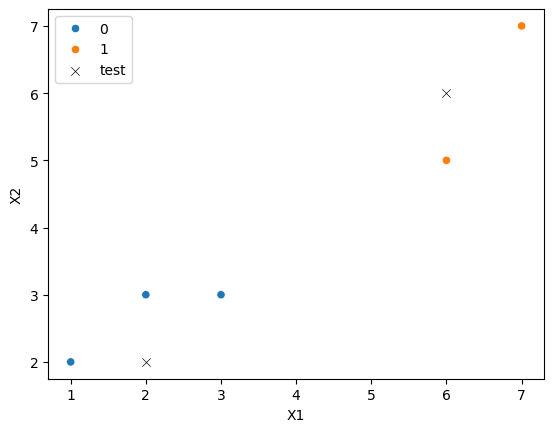

In [ ]:
# visiualise
X_train_df = pd.DataFrame(X_train, columns=["X1", "X2"])
X_train_df["label"] = y_train

sns.scatterplot(data=X_train_df, x="X1", y="X2", hue="label")
X_test_df = pd.DataFrame(X_test, columns=["X1", "X2"])
# X_test_df['label'] = y_test

sns.scatterplot(
    data=X_test_df, x="X1", y="X2", color="black", marker="x", label="test points"
)

In [6]:
X_train_df

,X1,X2,label
0,1,2,0
1,2,3,0
2,3,3,0
3,6,5,1
4,7,7,1
